<a href="https://colab.research.google.com/github/Sebacaraballo/ME239---Data-Science-for-ME/blob/main/lecture12/homework_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(lecture12:homework)=
# Homework 12

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Sebastian
+ **Last Name:** Caraballo
+ **Email:** scarabal@purdue.edu

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import numpy as np
import scipy.stats as st

/tmp/ipykernel_2824/122018214.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


(lecture12:homework:problem2)=
## Problem 1 - Comparing performance of robotic systems

You are considering purchasing a robotic system for manufacturing masks.
There are two possibilities, say $A$ and $B$.
They both produce the same number of masks per day, they cost the same to purchase, and the have the same power and supply costs.
However, they are not identical. They have different faulty mask rates.
Let $X_A$ and $X_B$ be the number of faulty masks you get from each system, respectively, in a given day.
For each of the possibilities below:

1) Use `scipy.stats` to make two Normal random variables $X_A$ and $X_B$ with the right mean and variance.

2) Plot the PDF of the random variables in the same figure.

3) Find a 95% central credible interval.

3) Indicate which robotic system you would buy and why (three choices $A$, $B$, and ``I cannot choose'').


+ **Case 1:** $\mathbf{E}[X_A] = 1, \mathbf{V}[X_A] = 0.1$ and $\mathbf{E}[X_B] = 1, \mathbf{V}[X_B] = 0.2$.

**Answer:**

In [2]:
from scipy import stats as st
import numpy as np

XA = st.norm(loc=1, scale=np.sqrt(0.1))
XB = st.norm(loc=1, scale=np.sqrt(0.2))

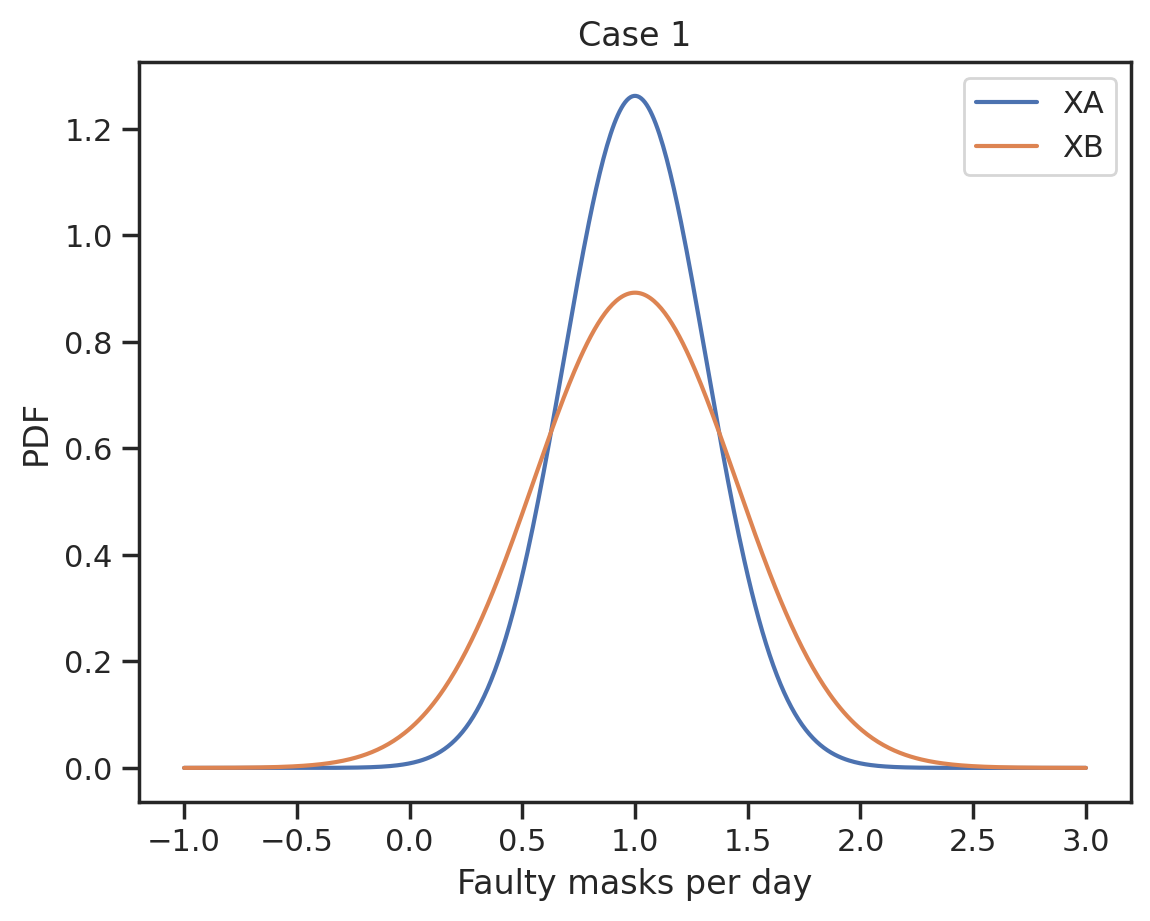

In [3]:
x = np.linspace(-1, 3, 500)
fig, ax = plt.subplots()
ax.plot(x, XA.pdf(x), label='XA')
ax.plot(x, XB.pdf(x), label='XB')
ax.set_xlabel('Faulty masks per day')
ax.set_ylabel('PDF')
ax.set_title('Case 1')
ax.legend();

In [4]:
print('XA 95% CI:', XA.interval(0.95))

XA 95% CI: (np.float64(0.38020496769543843), np.float64(1.6197950323045616))


In [5]:
print('XB 95% CI:', XB.interval(0.95))

XB 95% CI: (np.float64(0.12347745942341848), np.float64(1.8765225405765815))


*Your answer to which one you would buy and why here.*

+ **Case 2:** $\mathbf{E}[X_A] = 1, \mathbf{V}[X_A] = 0.1$ and $\mathbf{E}[X_B] = 2, \mathbf{V}[X_B] = 0.1$.

**Answer:**

I would buy A. Both have the same mean (same average faulty rate), but XA has lower variance, meaning it is more predictable and consistent. Lower variance means fewer surprise days with many faulty masks.

In [6]:
XA = st.norm(loc=1, scale=np.sqrt(0.1))
XB = st.norm(loc=2, scale=np.sqrt(0.1))

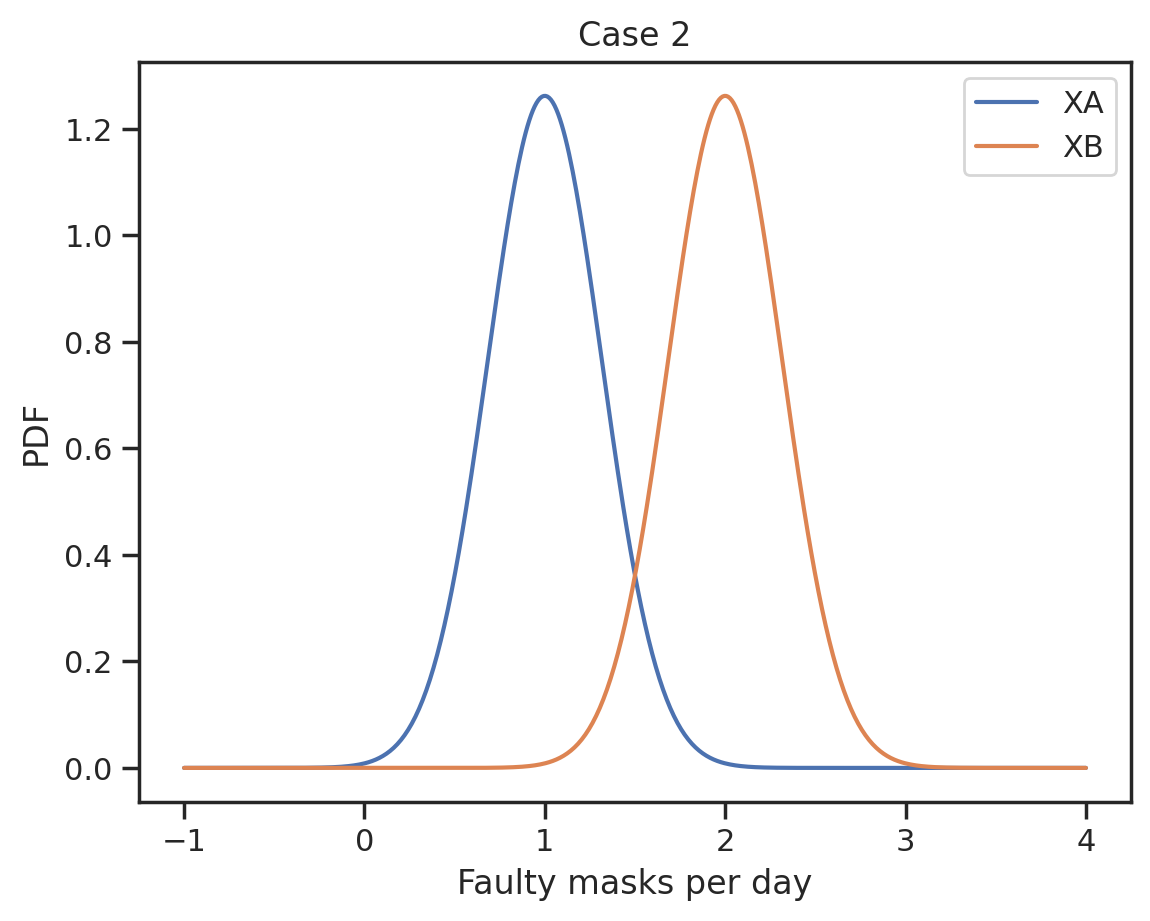

In [7]:
x = np.linspace(-1, 4, 500)
fig, ax = plt.subplots()
ax.plot(x, XA.pdf(x), label='XA')
ax.plot(x, XB.pdf(x), label='XB')
ax.set_xlabel('Faulty masks per day')
ax.set_ylabel('PDF')
ax.set_title('Case 2')
ax.legend();

In [8]:
print('XA 95% CI:', XA.interval(0.95))

XA 95% CI: (np.float64(0.38020496769543843), np.float64(1.6197950323045616))


In [9]:
print('XB 95% CI:', XB.interval(0.95))

XB 95% CI: (np.float64(1.3802049676954384), np.float64(2.6197950323045616))


*Your answer to which one you would buy and why here.*

+ **Case 3:** $\mathbf{E}[X_A] = 1, \mathbf{V}[X_A] = 0.3$ and $\mathbf{E}[X_B] = 1.1, \mathbf{V}[X_B] = 0.1$.

**Answer:**
I would buy A. XA produces on average only 1 faulty mask per day versus 2 for XB, with equal variance. XA is clearly better.

In [10]:
XA = st.norm(loc=1, scale=np.sqrt(0.3))
XB = st.norm(loc=1.1, scale=np.sqrt(0.1))

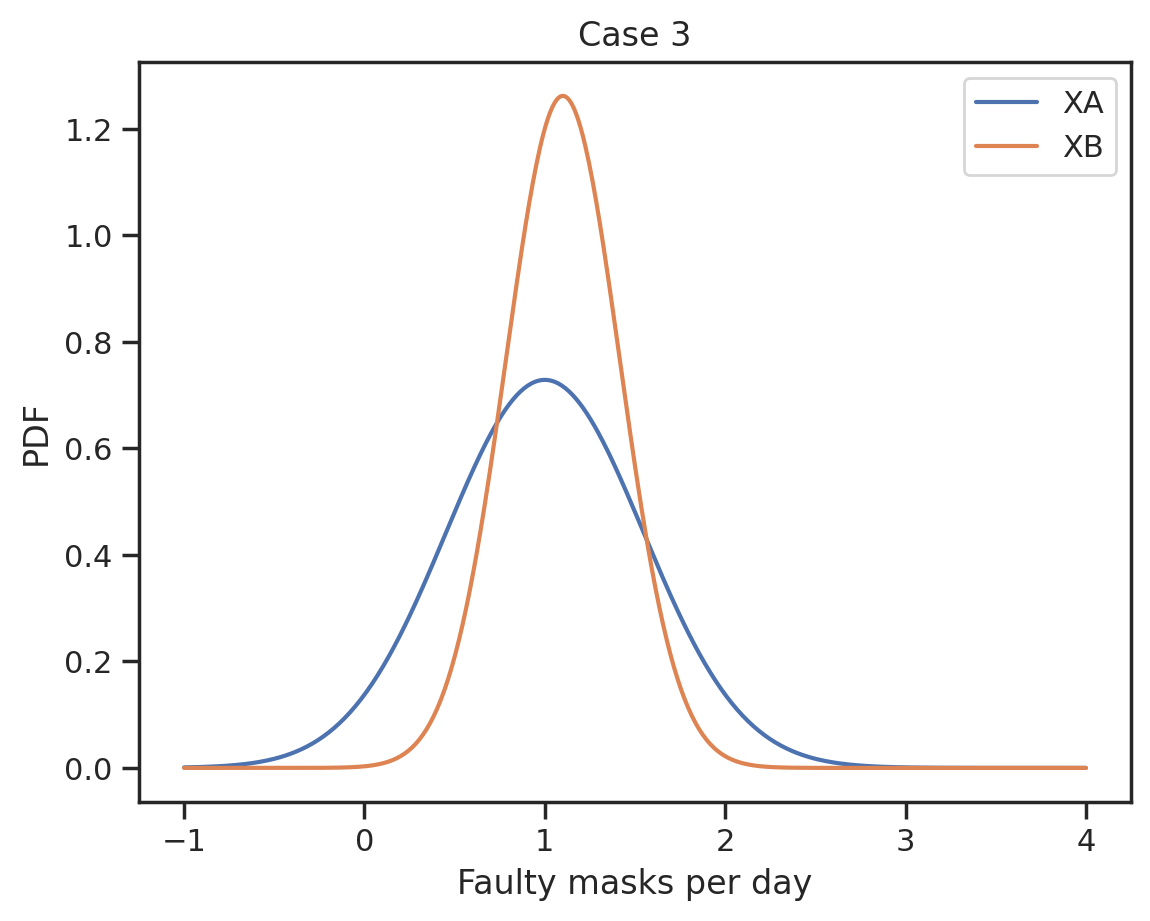

In [11]:
x = np.linspace(-1, 4, 500)
fig, ax = plt.subplots()
ax.plot(x, XA.pdf(x), label='XA')
ax.plot(x, XB.pdf(x), label='XB')
ax.set_xlabel('Faulty masks per day')
ax.set_ylabel('PDF')
ax.set_title('Case 3')
ax.legend();

In [12]:
print('XA 95% CI:', XA.interval(0.95))

XA 95% CI: (np.float64(-0.07351648623029416), np.float64(2.073516486230294))


In [13]:
print('XB 95% CI:', XB.interval(0.95))

XB 95% CI: (np.float64(0.4802049676954385), np.float64(1.7197950323045617))


I would buy B. XB has a slightly higher mean (1.1 vs 1.0) but much lower variance. The credible interval for XB is much tighter, meaning it is far more consistent and predictable. The small difference in mean is outweighed by the reliability advantage.

## Problem 2 - Figuring out which household conserves less energy

In this homework problem, we are going to look at a dataset for which the Normal is not a good fit.
In particular, we are going to look at HVAC energy consumption in our high-performance building data.

In [14]:
import requests
import os

# The url of the file we want to download
url = 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-297-intro-to-data-science/master/data/temperature_raw.xlsx'
!curl -O $url

import numpy as np
import pandas as pd
df = pd.read_excel('temperature_raw.xlsx')
df = df.dropna(axis=0)
df.date = pd.to_datetime(df['date'], format='%Y-%m-%d')
df

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  277k  100  277k    0     0  1026k      0 --:--:-- --:--:-- --:--:-- 1029k


,household,date,score,t_out,t_unit,hvac
0,a1,2018-01-07,100.0,4.283373,66.693229,246.473231
1,a10,2018-01-07,100.0,4.283373,66.356134,5.492116
2,a11,2018-01-07,58.0,4.283373,71.549132,402.094327
3,a12,2018-01-07,64.0,4.283373,73.429514,211.692244
4,a13,2018-01-07,100.0,4.283373,63.923937,0.850536
...,...,...,...,...,...,...
5643,c44,2020-02-25,59.0,43.642388,76.494637,19.135139
5644,c45,2020-02-25,87.0,43.642388,71.165052,30.794281
5646,c47,2020-02-25,97.0,43.642388,68.603287,5.339391
5647,c48,2020-02-25,92.0,43.642388,73.429239,18.040078


+ Extract the `hvac` column for household `a5`:

In [16]:
hvac_a5 = df[df['household'] == 'a5']['hvac']

+ Do the histogram of `hvac` for household `a5`:

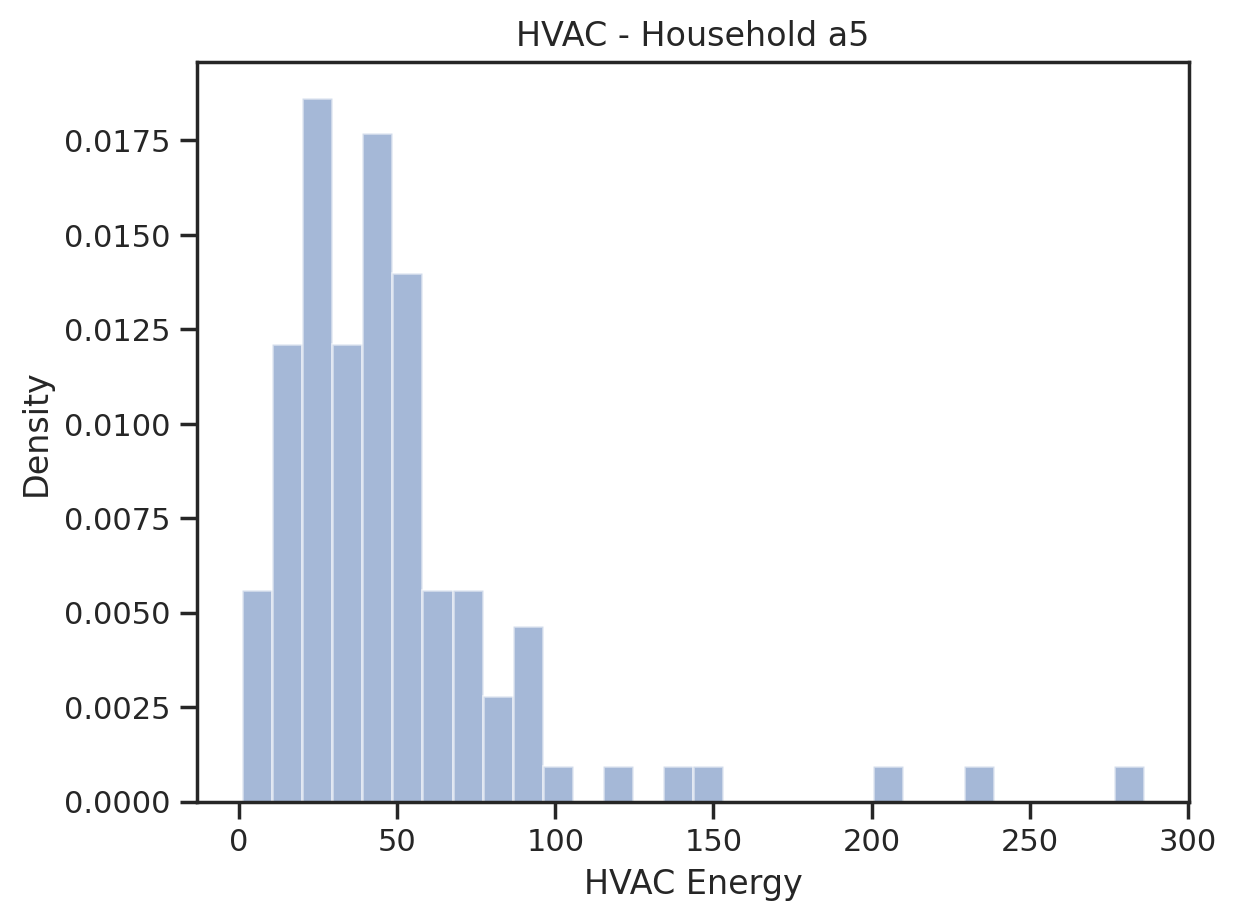

In [17]:
fig, ax = plt.subplots()
ax.hist(hvac_a5, density=True, alpha=0.5, bins=30)
ax.set_xlabel('HVAC Energy')
ax.set_ylabel('Density')
ax.set_title('HVAC - Household a5');

+ Use the method of moments to fit a Normal distribution to the `hvac` data for household `a5`:

In [18]:
HVAC_a5 = st.norm(loc=hvac_a5.mean(), scale=hvac_a5.std())

+ In the same figure, show the histogram of `hvac` data for household `a5` (use `density=True` to make sure itis normalized) and the PDF of the Normal you just fitted.
Is this a good fit? Why do you think we do not get a good fit?

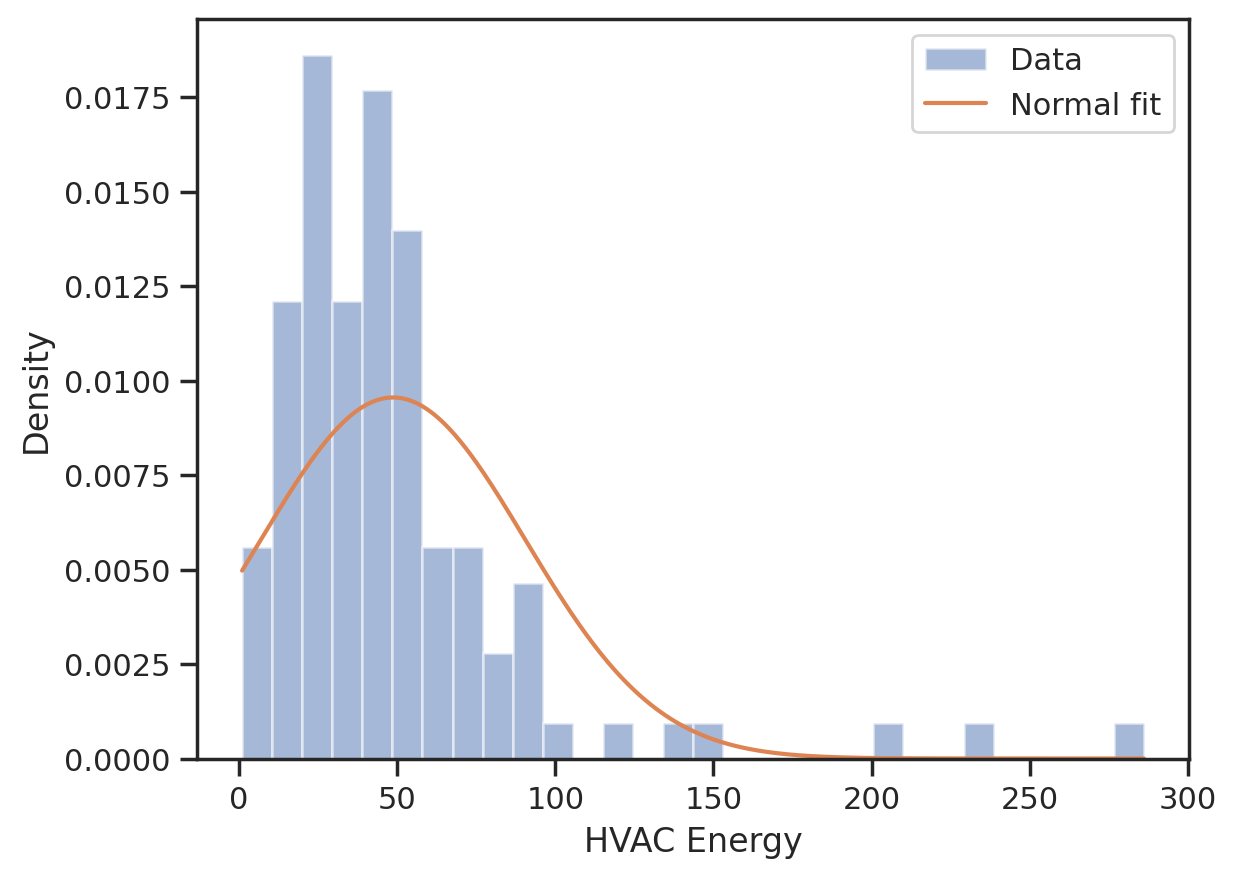

In [19]:
x = np.linspace(hvac_a5.min(), hvac_a5.max(), 500)
fig, ax = plt.subplots()
ax.hist(hvac_a5, density=True, alpha=0.5, bins=30, label='Data')
ax.plot(x, HVAC_a5.pdf(x), label='Normal fit')
ax.set_xlabel('HVAC Energy')
ax.set_ylabel('Density')
ax.legend();

The Normal is not a good fit because the HVAC data is strictly positive and right-skewed — it has a long tail on the right. The Normal is symmetric and allows negative values, which is physically impossible for energy consumption.

+ Now I am asking you to transform the data in a way that will make them look more Normal.
Do the histogram of the logarithm of the `hvac` data for household `a5`:

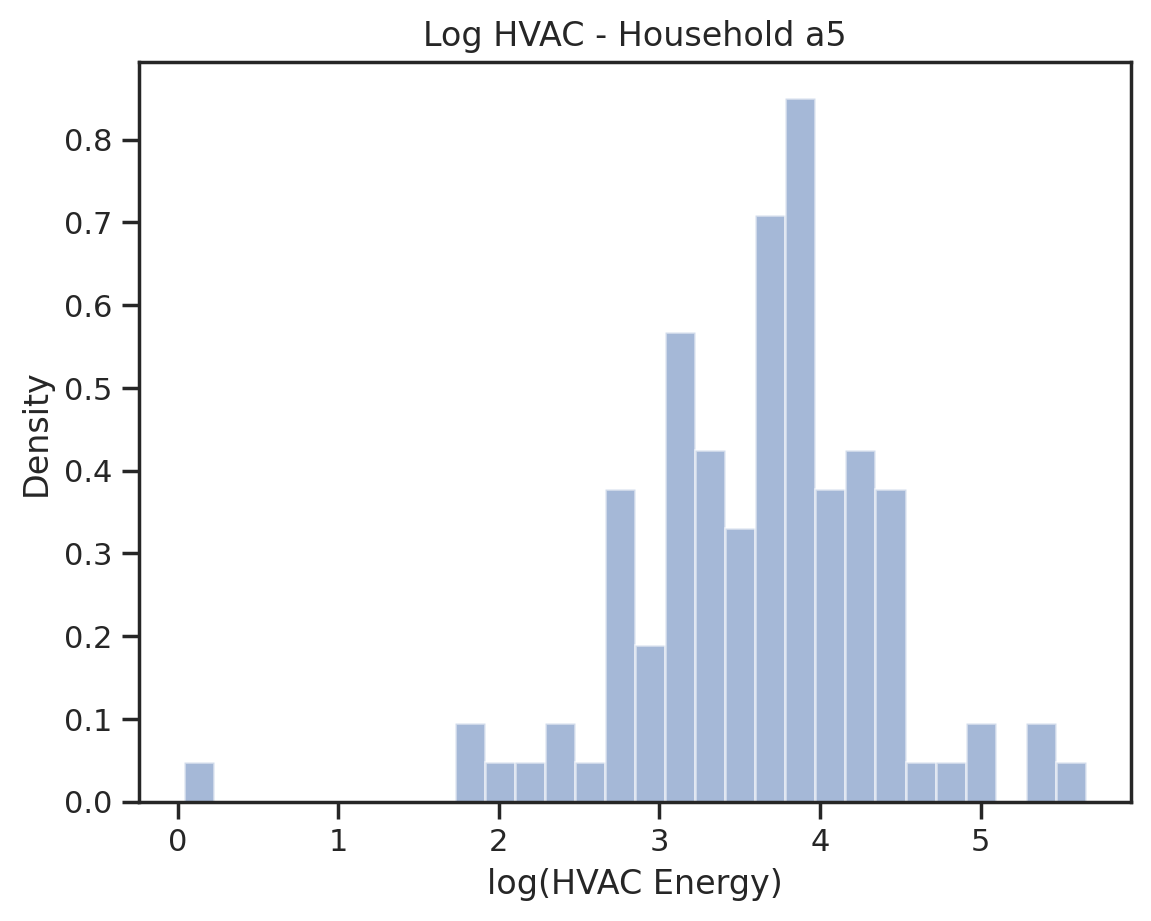

In [20]:
log_hvac_a5 = np.log(hvac_a5)
fig, ax = plt.subplots()
ax.hist(log_hvac_a5, density=True, alpha=0.5, bins=30)
ax.set_xlabel('log(HVAC Energy)')
ax.set_ylabel('Density')
ax.set_title('Log HVAC - Household a5');

+ Fit a Normal to the logarithm of the `hvac` data for household `a5`:

In [21]:
LOG_HVAC_a5 = st.norm(loc=log_hvac_a5.mean(), scale=log_hvac_a5.std())

+ In the same figure, show the histogram of the **logarithm** of the `hvac` data for household `a5` and the PDF of the Normal you just fitted. Does this look like a good fit?

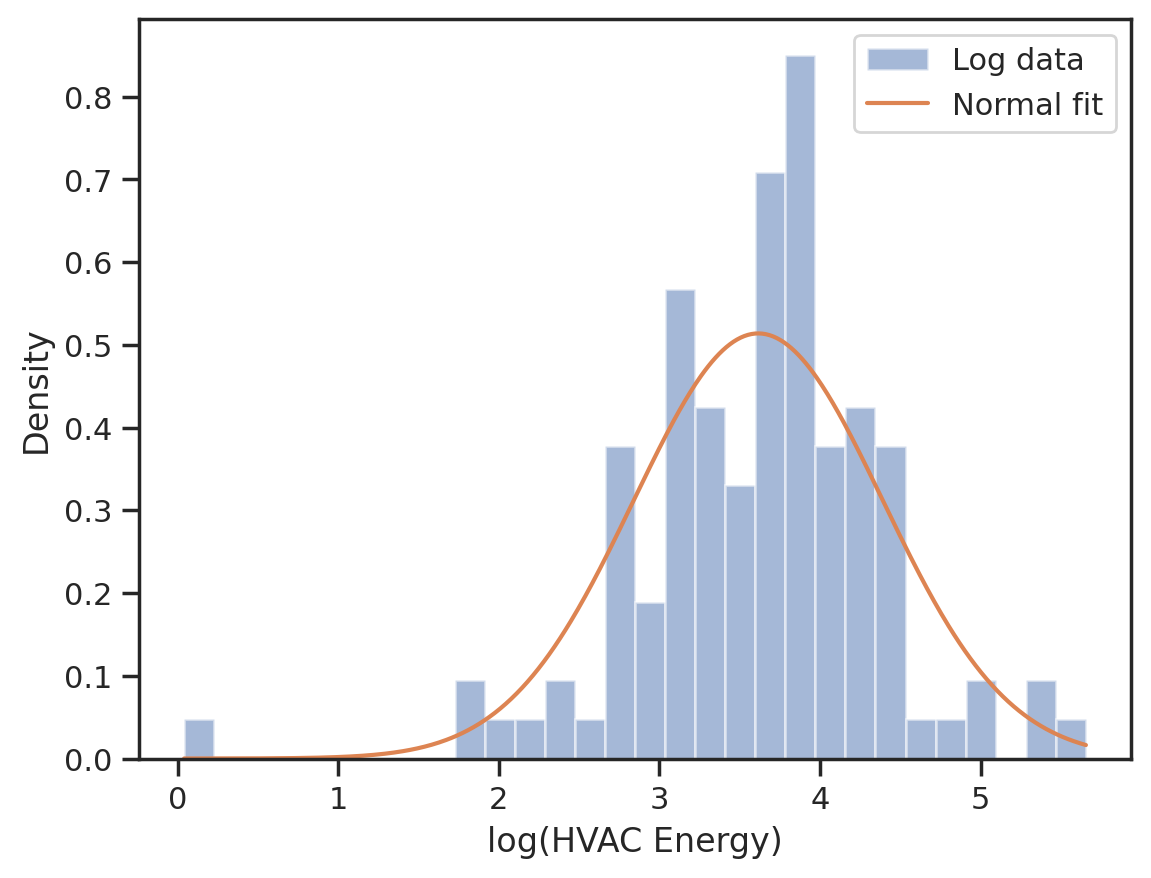

In [22]:
x = np.linspace(log_hvac_a5.min(), log_hvac_a5.max(), 500)
fig, ax = plt.subplots()
ax.hist(log_hvac_a5, density=True, alpha=0.5, bins=30, label='Log data')
ax.plot(x, LOG_HVAC_a5.pdf(x), label='Normal fit')
ax.set_xlabel('log(HVAC Energy)')
ax.set_ylabel('Density')
ax.legend();

This is a much better fit. The log-transformed data looks approximately Normal and symmetric.

+ Now do exactly the same thing as the previous bullet point for household `a3`.

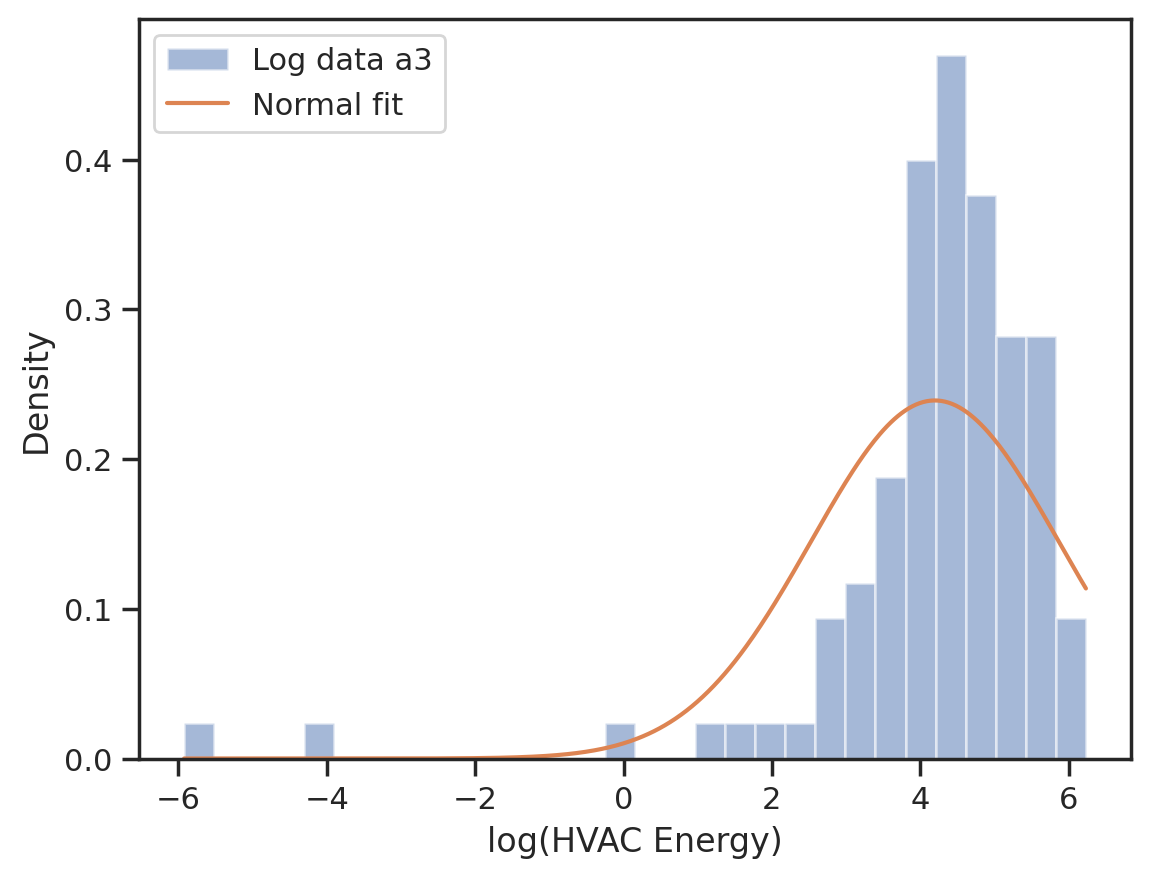

In [23]:
hvac_a3 = df[df['household'] == 'a3']['hvac']
log_hvac_a3 = np.log(hvac_a3)
LOG_HVAC_a3 = st.norm(loc=log_hvac_a3.mean(), scale=log_hvac_a3.std())

x = np.linspace(log_hvac_a3.min(), log_hvac_a3.max(), 500)
fig, ax = plt.subplots()
ax.hist(log_hvac_a3, density=True, alpha=0.5, bins=30, label='Log data a3')
ax.plot(x, LOG_HVAC_a3.pdf(x), label='Normal fit')
ax.set_xlabel('log(HVAC Energy)')
ax.set_ylabel('Density')
ax.legend();

+ Which household consumes more energy, `a5` or `a3`?

In [24]:
print(f'a5 mean log HVAC: {log_hvac_a5.mean():.3f}')
print(f'a3 mean log HVAC: {log_hvac_a3.mean():.3f}')

a5 mean log HVAC: 3.615
a3 mean log HVAC: 4.196


The household with the higher mean log HVAC consumes more energy on average.


## Problem 3 - Introducing the Log-Normal distribution

In the previous problem, we took the logarithm of `hvac` in order to obtain a better fit to the Normal.
It turns out that this is a very common practice whenever you have a positive dataset that is skewed in the way we noticed above.
As a matter of fact, there is a distribution called the [Log-Normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution) which is designed to do exactly that.
Below, I show you could have fitted a Log-Normal distribution directly on the `hvac` data.

In [25]:
params = st.lognorm.fit(hvac_a5) # This does something similar to the method of moments
HVAC_a5_ln = st.lognorm(*params) # This is the random varibale
# Here is how you can sample from it:
HVAC_a5_ln.rvs(size=10)

array([ 59.03642483, 120.79065948,  22.79737203,  21.38292586,
        59.85735448, 102.39829446,  63.22945466,  72.72173244,
        56.60022967,  42.72535642])

In [26]:
# Here is how you can evaluate its PDF:
HVAC_a5_ln.pdf(200)

np.float64(0.00014185114943067792)

+ In the same figure, plot the PDF of the Log-normal along with the histogram of the `hvac` data for `a5`.

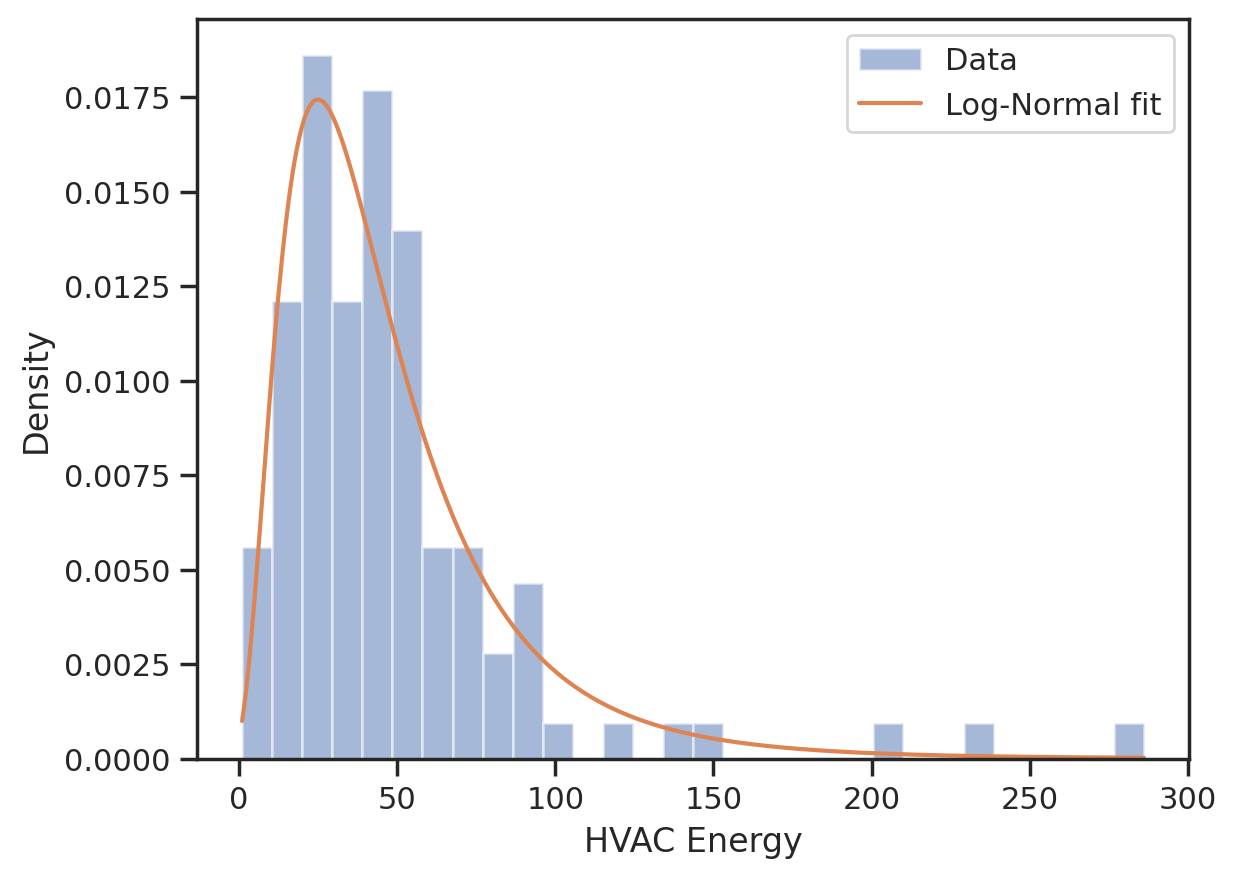

In [27]:
params = st.lognorm.fit(hvac_a5)
HVAC_a5_ln = st.lognorm(*params)

x = np.linspace(hvac_a5.min(), hvac_a5.max(), 500)
fig, ax = plt.subplots()
ax.hist(hvac_a5, density=True, alpha=0.5, bins=30, label='Data')
ax.plot(x, HVAC_a5_ln.pdf(x), label='Log-Normal fit')
ax.set_xlabel('HVAC Energy')
ax.set_ylabel('Density')
ax.legend();

+ Is the fit with Log-Normal good?

Yes, the Log-Normal fit is much better than the Normal fit directly on the raw data.



+ Recall how in [](lecture12:standard-normal-quantiles) we used the `ppf()` function of a random variable to find quantiles.
Use this function to find the 0.025-quantile of the Log-Normal we constructed above.

In [28]:
print('0.025 quantile:', HVAC_a5_ln.ppf(0.025))

0.025 quantile: 7.491637161895099


+ Now find the 95% central credible interval of the Log-Normal variable we constructed above.

In [29]:
print('a5 95% CI:', HVAC_a5_ln.interval(0.95))

a5 95% CI: (np.float64(7.4916371618951025), np.float64(142.8030915978453))


+ Repeat as many code-blocks as you need to fit a Log-Normal to the `hvac` data for household `a3` and then find the 95% central credible interval of the resulting random variable.

In [30]:
params_a3 = st.lognorm.fit(hvac_a3)
HVAC_a3_ln = st.lognorm(*params_a3)
print('a3 95% CI:', HVAC_a3_ln.interval(0.95))

a3 95% CI: (np.float64(4.242938856830953), np.float64(418.6688283685003))


+ By comparing the 95% central credible intervals constructed above, which household `a5` or `a3` consumes more energy?

Compare the 95% credible intervals and medians. The household whose interval is shifted toward higher values consumes more energy. The Log-Normal median (which equals e^μ) is the best measure of central tendency here since the distribution is skewed.


In [31]:
print(f'a5 median: {HVAC_a5_ln.median():.2f}')
print(f'a3 median: {HVAC_a3_ln.median():.2f}')

a5 median: 39.00
a3 median: 87.17


Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_12.ipynb'